In [1]:
from pathlib import Path
import pandas as pd

excel_path = Path(r"C:\Users\anule\OneDrive\Documents\OASIS INFOBYTE\Task 1 -Retail Sales EDA\data\Global Retail Solutions company dataset.xlsx")

if not excel_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {excel_path}"
    )

df = pd.read_excel(excel_path)

print("Dataset loaded successfully!")
print("Dataset path:", excel_path)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Dataset path: C:\Users\anule\OneDrive\Documents\OASIS INFOBYTE\Task 1 -Retail Sales EDA\data\Global Retail Solutions company dataset.xlsx
Number of rows: 200
Number of columns: 12


,Product Category,Product Name,REGION,Sales Amount,Quantity,Order Date,Customer ID,Customer Age,Customer Gender,Sales,Discount,Profit
0,Electronics,Smartphone,AMERICAS,500,1,2024-01-10,C001,25,Male,500,0.19,405.0
1,Apparel,T-Shirt,EUROPE,20,2,2024-01-11,C002,30,Female,20,0.23,15.4
2,Electronics,Laptop,ASIA,800,1,2024-01-12,C003,22,Female,800,0.20,640.0
3,Home Appliances,Microwave Oven,EUROPE,150,1,2024-01-13,C004,45,Male,150,0.19,121.5
4,Electronics,Headphones,AMERICAS,100,3,2024-01-14,C005,34,Male,100,0.16,84.0


## 1. Initial Dataset Inspection

The dataset is inspected to understand its structure, data types, dimensions, and overall contents.

In [7]:
# Display the shape of the dataset
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display first 5 rows
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (200, 12)

Column Names:
['Product Category', 'Product Name', 'REGION', 'Sales Amount', 'Quantity', 'Order Date', 'Customer ID', 'Customer Age', 'Customer Gender', 'Sales', 'Discount', 'Profit']

Data Types:
Product Category        str
Product Name            str
REGION                  str
Sales Amount          int64
Quantity              int64
Order Date              str
Customer ID             str
Customer Age          int64
Customer Gender         str
Sales                 int64
Discount            float64
Profit              float64
dtype: object

First 5 Rows:


,Product Category,Product Name,REGION,Sales Amount,Quantity,Order Date,Customer ID,Customer Age,Customer Gender,Sales,Discount,Profit
0,Electronics,Smartphone,AMERICAS,500,1,2024-01-10,C001,25,Male,500,0.19,405.0
1,Apparel,T-Shirt,EUROPE,20,2,2024-01-11,C002,30,Female,20,0.23,15.4
2,Electronics,Laptop,ASIA,800,1,2024-01-12,C003,22,Female,800,0.20,640.0
3,Home Appliances,Microwave Oven,EUROPE,150,1,2024-01-13,C004,45,Male,150,0.19,121.5
4,Electronics,Headphones,AMERICAS,100,3,2024-01-14,C005,34,Male,100,0.16,84.0


## 2. Missing Value Check

Missing values are checked to ensure that the dataset is complete before performing further analysis.

In [8]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
Product Category    0
Product Name        0
REGION              0
Sales Amount        0
Quantity            0
Order Date          0
Customer ID         0
Customer Age        0
Customer Gender     0
Sales               0
Discount            0
Profit              0
dtype: int64

Total missing values: 0


### Observation

The dataset contains no missing values in any of the 12 columns. Therefore, no missing-value treatment or imputation is required, and the dataset can be used directly for further analysis.

In [9]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


### Observation

No duplicate records are present in the dataset. This indicates that each row represents a unique sales transaction.

## 3. Descriptive Statistics

Descriptive statistics are calculated for all numerical columns to understand the central tendency and variation in the retail sales data.

In [11]:
# Complete descriptive statistics
statistics = pd.DataFrame({
    'Mean': df[numeric_columns].mean(),
    'Median': df[numeric_columns].median(),
    'Mode': df[numeric_columns].mode().iloc[0],
    'Standard Deviation': df[numeric_columns].std()
})

statistics

,Mean,Median,Mode,Standard Deviation
Sales Amount,736.84000,705.500,400.00,443.182443
Quantity,2.42500,2.000,1.00,1.162381
Customer Age,38.54000,37.500,35.00,11.840583
Sales,736.84000,705.500,400.00,443.182443
Discount,0.17470,0.185,0.20,0.070980
Profit,610.80985,588.000,597.24,376.686834


### Observation

The descriptive statistics show the central values and variation of the numerical variables. The average sales amount is about 736.84, while the average quantity sold per transaction is about 2.43 units. The average customer age is approximately 38.54 years. The average discount is about 17.47%, and the average profit is approximately 610.81.

In [12]:
# Convert Order Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Check the date range
print("Minimum Order Date:", df['Order Date'].min())
print("Maximum Order Date:", df['Order Date'].max())

Minimum Order Date: 2024-01-10 00:00:00
Maximum Order Date: 2024-07-27 00:00:00


In [ ]:
## 4. Time Series Analysis

Monthly sales are analyzed to identify changes and trends in sales performance over time.

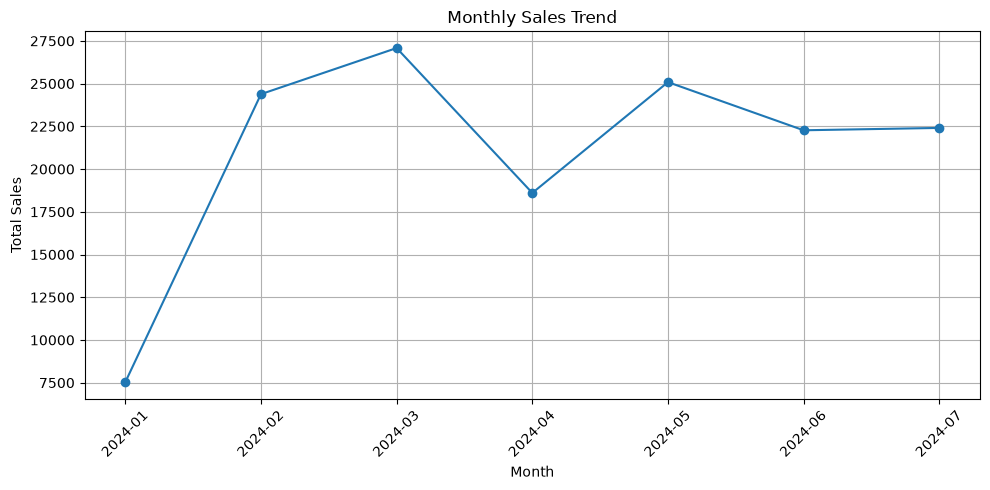

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate monthly sales
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

# Convert period to string for plotting
monthly_sales.index = monthly_sales.index.astype(str)

# Plot monthly sales
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

Sales increase sharply from January to February and reach the highest monthly value in March. Sales decrease in April but increase again in May. June and July show relatively stable sales compared with the previous months. Overall, March records the highest monthly sales, while January records the lowest.

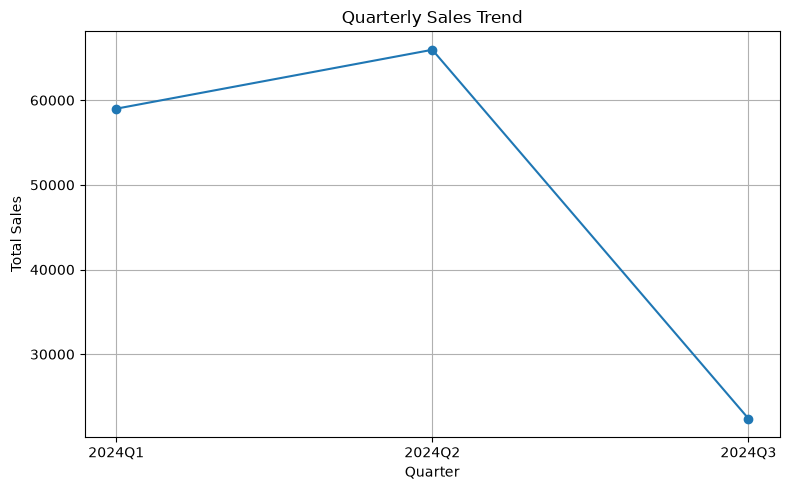

In [14]:
# Calculate quarterly sales
quarterly_sales = df.groupby(
    df['Order Date'].dt.to_period('Q')
)['Sales'].sum()

quarterly_sales.index = quarterly_sales.index.astype(str)

# Plot quarterly sales
plt.figure(figsize=(8, 5))

plt.plot(
    quarterly_sales.index,
    quarterly_sales.values,
    marker='o'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

The second quarter records the highest sales with total sales of 65,960, compared with 59,000 in the first quarter. The third quarter has lower sales because the dataset contains only July transactions for this quarter. Therefore, the Q3 value should not be directly compared with complete quarters.

## 5. Customer Demographics Analysis

Customer age and gender are analyzed to understand the demographic distribution of the retail customers.

Age Group
Below 18     4
18-25       29
26-35       54
36-45       53
46-60       60
Name: count, dtype: int64


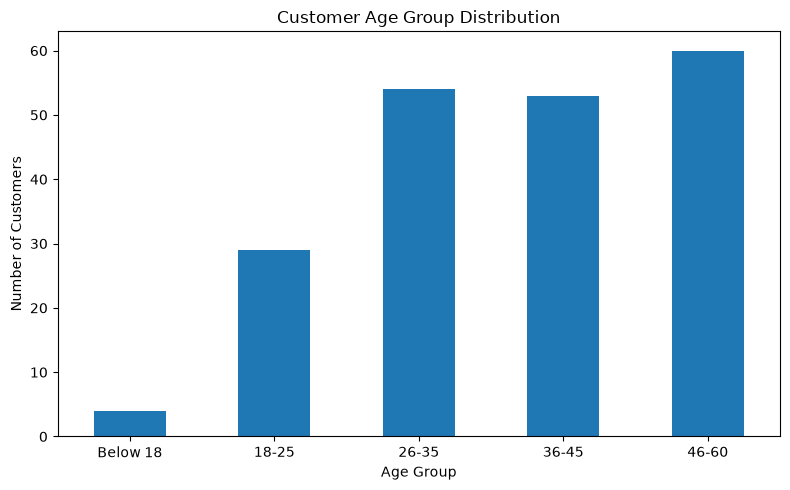

In [15]:
# Create age groups
df['Age Group'] = pd.cut(
    df['Customer Age'],
    bins=[0, 18, 25, 35, 45, 60],
    labels=['Below 18', '18-25', '26-35', '36-45', '46-60']
)

# Count customers in each age group
age_groups = df['Age Group'].value_counts().sort_index()

print(age_groups)

# Plot
plt.figure(figsize=(8, 5))

age_groups.plot(kind='bar')

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

Customers aged 46–60 form the largest age group with 60 customers. The 26–35 and 36–45 age groups also represent a substantial portion of the customer base. Customers below 18 represent the smallest group with only 4 customers.

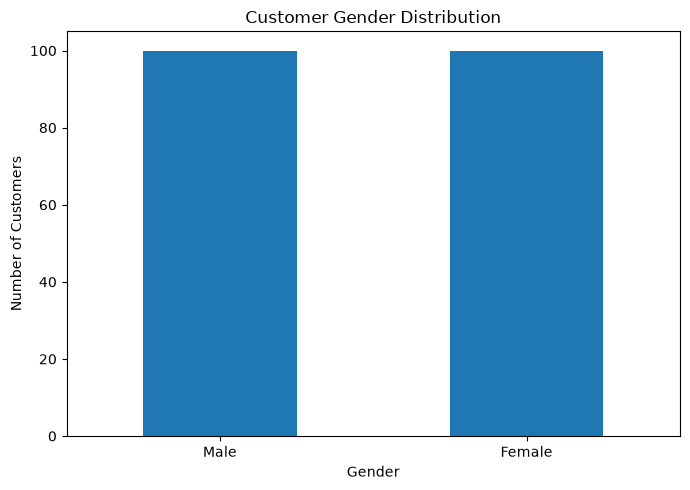

In [16]:
# Count customers by gender
gender_counts = df['Customer Gender'].value_counts()

# Plot gender distribution
plt.figure(figsize=(7, 5))

gender_counts.plot(kind='bar')

plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

The dataset has an equal distribution of male and female customers, with 100 customers in each group. This provides a balanced representation of gender in the dataset.

## 6. Product Analysis

The top 10 best-selling products are identified based on the total quantity sold.

In [17]:
# Calculate total quantity sold for each product
top_products = (
    df.groupby('Product Name')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Smartphone         33
Hat                33
Jacket             32
Microwave Oven     31
Refrigerator       30
Gaming Console     30
Tablet             28
Air Conditioner    27
Laptop             27
Jeans              27
Name: Quantity, dtype: int64


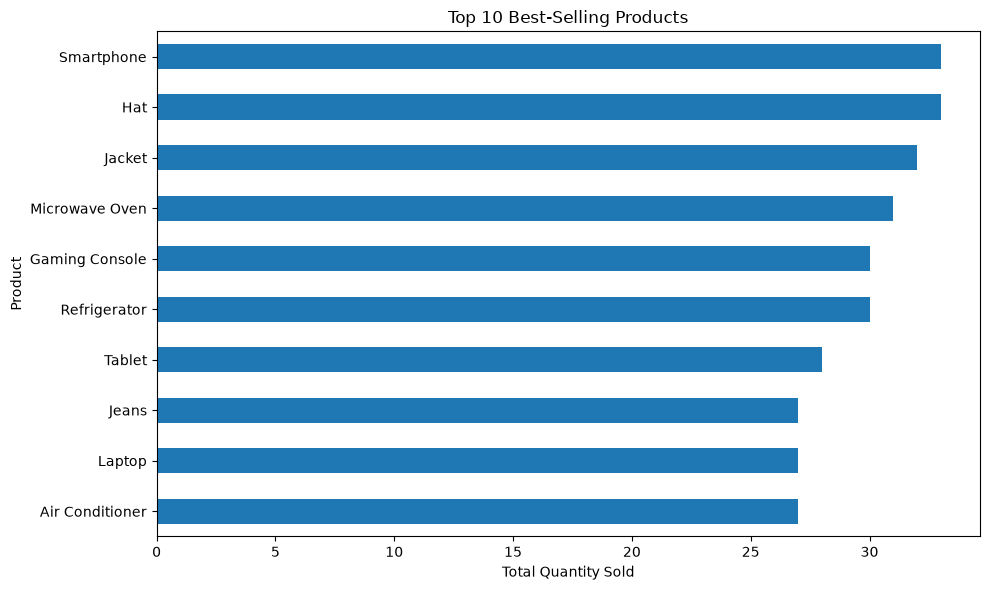

In [18]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

### Observation

Smartphone and Hat have the highest total quantity sold, with 33 units each. Jacket follows with 32 units. The results show that both electronic products and apparel products appear among the most frequently purchased items.

Product Category
Apparel            49467
Electronics        49329
Home Appliances    48572
Name: Sales, dtype: int64


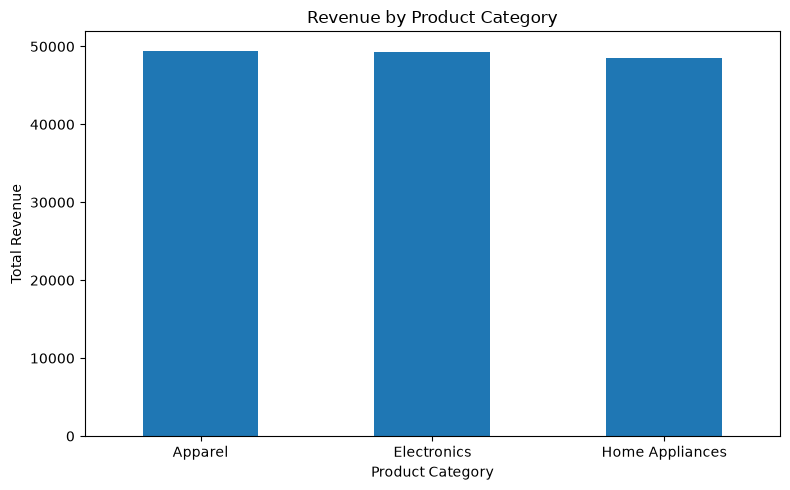

In [19]:
# Calculate revenue by product category
category_sales = (
    df.groupby('Product Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

# Plot
plt.figure(figsize=(8, 5))

category_sales.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

Apparel generates the highest revenue at 49,467, followed closely by Electronics at 49,329. Home Appliances generate 48,572. The revenue contribution of all three categories is relatively balanced.

## 7. Correlation Analysis

A correlation heatmap is used to examine relationships between numerical variables such as sales, quantity, discount, customer age, and profit.

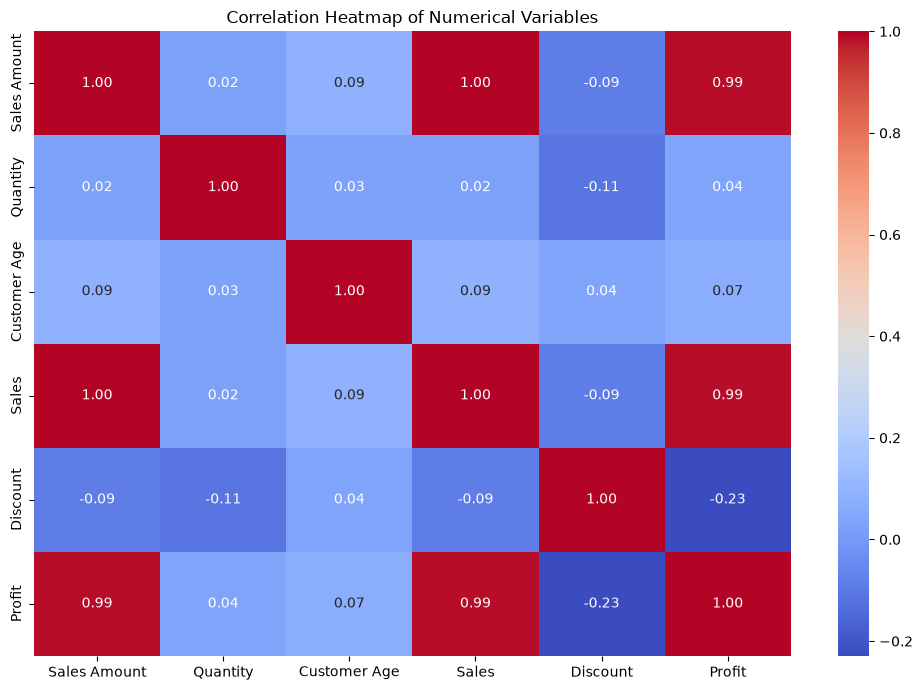

In [20]:
# Select numerical columns
correlation = df.select_dtypes(include='number').corr()

# Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

### Observation

The heatmap shows a very strong positive correlation between Sales and Profit, with a correlation coefficient of approximately 0.986. Quantity has a very weak relationship with Sales. Discount has a weak negative relationship with Sales and a somewhat stronger negative relationship with Profit. This suggests that higher discounts are associated with lower profit in this dataset.

## 8. Additional Visualization: Discount vs Profit

The relationship between discount percentage and profit is analyzed to understand whether higher discounts are associated with lower profitability.

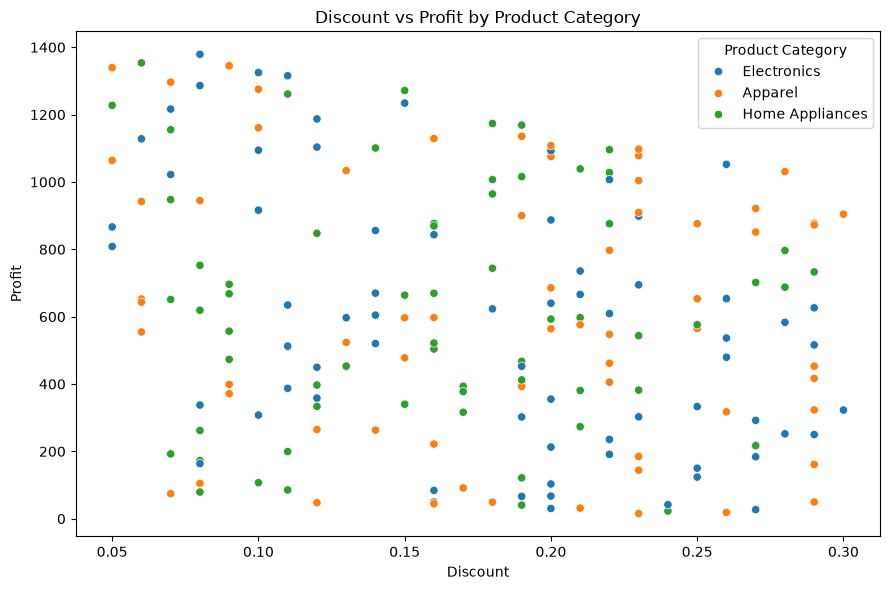

In [21]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Product Category'
)

plt.title('Discount vs Profit by Product Category')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

### Observation

The scatter plot shows a generally negative relationship between discount and profit. The correlation between discount and profit is approximately -0.229, indicating that higher discounts tend to be associated with lower profit. However, the relationship is not very strong, suggesting that other factors also influence profitability.

## 9. Regional Sales Analysis

Sales performance is compared across different regions to identify regional differences in revenue.

REGION
AMERICAS    40040
EUROPE      38876
AFRICA      37796
ASIA        30656
Name: Sales, dtype: int64


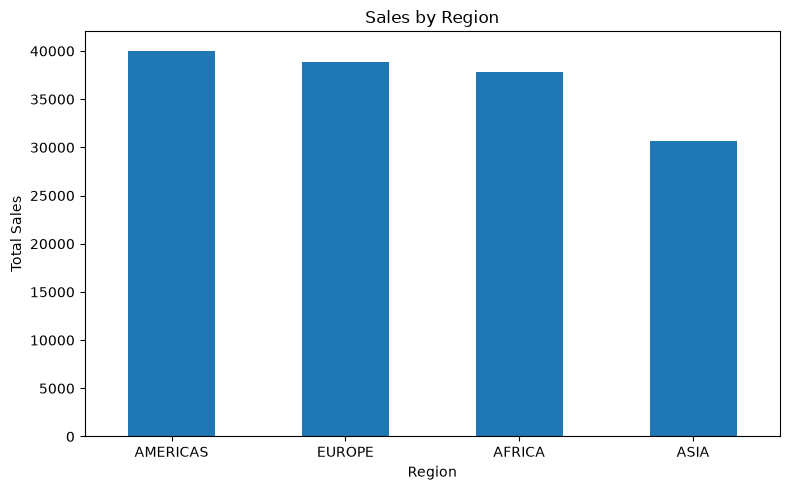

In [22]:
# Calculate sales by region
region_sales = (
    df.groupby('REGION')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

# Plot
plt.figure(figsize=(8, 5))

region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

The Americas generate the highest sales with 40,040, followed by Europe with 38,876. Asia records the lowest sales among the four regions with 30,656. This indicates differences in regional sales performance that may require further investigation.

## 10. Business Recommendations

1. **Focus on high-selling products:** Smartphones, Hats, Jackets, and Microwave Ovens have high sales quantities. These products can be given better stock availability to reduce the possibility of stock shortages.

2. **Monitor discount levels:** The analysis shows a negative relationship between discount and profit. The company should monitor excessive discounts and use targeted promotional offers to maintain profitability.

3. **Strengthen regional sales:** The Americas generate the highest sales, while Asia has the lowest sales among the four regions. The company can study customer preferences in lower-performing regions and develop region-specific marketing strategies.

4. **Target major customer age groups:** Customers aged 46–60 form the largest age group. Marketing campaigns can be designed according to the purchasing preferences of this customer segment.

5. **Maintain category balance:** Apparel, Electronics, and Home Appliances generate relatively similar revenue. The company can continue maintaining a balanced product portfolio while identifying opportunities for category-specific growth.

## 11. Conclusion

The Exploratory Data Analysis of the Global Retail Solutions dataset provided useful insights into sales performance, customer demographics, products, and profitability.

The dataset contains 200 transactions and 12 columns, with no missing values or duplicate records. The average sales amount is approximately 736.84, while the average profit is approximately 610.81.

The time-series analysis shows that March recorded the highest monthly sales, while the second quarter recorded the highest quarterly sales. However, the third quarter contains only July data and therefore should not be compared directly with complete quarters.

Customer analysis shows that the 46–60 age group has the largest representation, while male and female customers are equally represented. Smartphone and Hat have the highest quantity sold among the products analyzed. Apparel generates the highest category revenue, although the three product categories have relatively similar revenue levels.

The correlation analysis shows a very strong positive relationship between sales and profit. The additional discount-profit analysis indicates that higher discounts are associated with lower profit, although the relationship is relatively weak.

Overall, the analysis provides useful information for inventory planning, customer targeting, regional marketing, product management, and discount strategy.